In [1]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import random
from xgboost import XGBClassifier
import lime
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import shap
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV

c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Preprocessing

In [2]:
directory_buggy = "D:\\ICSE_Dataset\\CSVAllBuggy"

In [41]:
import os
import pandas as pd

data_points = []

def convert_tensor_to_bool(tensor_str):
    if isinstance(tensor_str, str):
        return 'True' in tensor_str
    elif isinstance(tensor_str, bool):
        return tensor_str
    elif isinstance(tensor_str, int):
        return bool(tensor_str)
    return False

columns_to_delete = []

def process_directory(directory, label_filter):
    data_points = []
    for filename in os.listdir(directory):
        if filename.endswith('.csv') and any(label in filename for label in label_filter):
            label = next(label for label in label_filter if label in filename)
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            if 'dying_relu' in df.columns:
                df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
            df = df.drop(columns=columns_to_delete, errors='ignore')
            data_point = df.mean().to_frame().T
            data_point['label'] = label
            data_points.append(data_point)
    return data_points

label_filter = ['Activation', 'Layer', 'Loss', 'Optimization']
data_points_correct = process_directory(directory_buggy, label_filter)
data_points_hyperparameter = process_directory(directory_buggy, ['Hyperparameter'])
min_samples = min(len(data_points_correct), len(data_points_hyperparameter))
data_points_balanced = data_points_correct[:min_samples] + data_points_hyperparameter[:min_samples]
df_combined = pd.concat(data_points_balanced, ignore_index=True)
output_file = "D:\\ICSE_Dataset\\hyperparameter_correct_data.csv"
df_combined.to_csv(output_file, index=False)

   epoch  train_loss  train_acc  val_loss  val_acc  large_weight_count  \
0   24.5    2.302334   0.103912  2.303556   0.1095                 0.0   
1   24.5    2.302162   0.106308  2.302621   0.1010                 0.0   
2   24.5    2.302400   0.102262  2.303584   0.1020                 0.0   
3   24.5    2.302297   0.103786  2.303293   0.1030                 0.0   
4   24.5    2.302155   0.106588  2.303741   0.1005                 0.0   

   acc_gap_too_big  loss_oscillation  dying_relu  gradient_vanish  ...  \
0              0.0               0.0         1.0              1.0  ...   
1              0.0               0.0         1.0              1.0  ...   
2              0.0               0.0         1.0              1.0  ...   
3              0.0               0.0         1.0              1.0  ...   
4              0.0               0.0         1.0              1.0  ...   

   gradient_median  adjusted_lr  mean_activation  std_activation  mean_grad  \
0         0.000007     0.000179

,epoch,train_loss,train_acc,val_loss,val_acc,large_weight_count,acc_gap_too_big,loss_oscillation,dying_relu,gradient_vanish,...,gradient_median,adjusted_lr,mean_activation,std_activation,mean_grad,std_grad,cpu_utilization,gpu_memory_utilization,memory_usage,label
0,24.5,2.302334,0.103912,2.303556,0.1095,0.00,0.0,0.00,1.0,1.00,...,0.000007,0.000179,0.020234,0.001234,-0.000003,0.003347,3.340,355.931885,9.050,Layer
1,24.5,2.302162,0.106308,2.302621,0.1010,0.00,0.0,0.00,1.0,1.00,...,0.000006,0.000179,0.020180,0.001563,-0.000005,0.003122,3.378,377.343975,9.054,Layer
2,24.5,2.302400,0.102262,2.303584,0.1020,0.00,0.0,0.00,1.0,1.00,...,0.000029,0.000179,0.020049,0.000854,0.000004,0.003099,3.350,378.677734,9.110,Layer
3,24.5,2.302297,0.103786,2.303293,0.1030,0.00,0.0,0.00,1.0,1.00,...,0.000019,0.000179,0.020149,0.001255,0.000001,0.003438,3.652,378.677734,10.824,Layer
4,24.5,2.302155,0.106588,2.303741,0.1005,0.00,0.0,0.00,1.0,1.00,...,0.000015,0.000179,0.020198,0.001738,0.000008,0.003124,3.524,378.677734,10.972,Layer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5137,24.5,3350.279006,0.000000,1547.008201,0.0000,242.94,0.0,0.98,1.0,0.00,...,451.899300,0.001791,9.640529,0.000000,-8.755601,0.000000,27.952,1.149170,14.600,Hyperparameter
5138,24.5,1461.936873,0.000000,1394.617703,0.0000,40.98,0.0,0.98,1.0,0.00,...,4.962247,0.001791,11.137314,0.000000,-7.469500,0.000000,27.990,1.149170,14.700,Hyperparameter
5139,24.5,1493.555571,0.000000,1392.391719,0.0000,38.98,0.0,0.98,1.0,0.00,...,6.381533,0.001791,11.196921,0.000000,-8.106470,0.000000,28.416,1.149170,14.700,Hyperparameter
5140,24.5,0.693150,0.501555,0.693206,0.4965,0.00,0.0,0.00,0.0,1.00,...,0.000415,0.000179,0.173106,0.012240,0.000904,0.001270,1.862,11.561909,7.216,Hyperparameter


# Feature processing

In [2]:
# read the data from CSV 
data = pd.read_csv("D:\\ICSE_Dataset\\hyperparameter_correct_data.csv")
df_combined = data.copy()
df_combined['label'] = df_combined['label'].apply(lambda x: 1 if x == 'Hyperparameter' else 0)

In [3]:
X = df_combined.drop(columns=['label'])
y = df_combined['label']
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.max()), axis=0)
for column in X.columns:
    if X[column].isna().sum() > 0 or np.isinf(X[column]).sum() > 0:
        X[column] = X[column].replace([np.inf, -np.inf], np.nan).fillna(X[column].mean())
    lower_quantile = X[column].quantile(0.01)
    upper_quantile = X[column].quantile(0.99)

    X[column] = X[column].clip(lower=lower_quantile, upper=upper_quantile)
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.mean()), axis=0)
if X.isna().sum().sum() > 0 or np.isinf(X).sum().sum() > 0:
    print("There are still NaNs or infinite values in the DataFrame. Additional cleaning needed.")
else:
    print("Data cleaning completed successfully. No NaNs or infinite values remain.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)


Data cleaning completed successfully. No NaNs or infinite values remain.
X_train shape:  (4113, 31)
X_test shape:  (1029, 31)
y_train shape:  (4113, 2)
y_test shape:  (1029, 2)


Feature importance 

In [4]:
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

Feature ranking:
1. feature 29 (0.080175)
2. feature 23 (0.071137)
3. feature 28 (0.050437)
4. feature 30 (0.033819)
5. feature 9 (0.013800)
6. feature 7 (0.013217)
7. feature 6 (0.011467)
8. feature 4 (0.010690)
9. feature 2 (0.005539)
10. feature 8 (0.001944)
11. feature 21 (0.001166)
12. feature 24 (0.000875)
13. feature 10 (0.000292)
14. feature 5 (0.000097)
15. feature 0 (0.000097)
16. feature 19 (0.000097)
17. feature 16 (0.000000)
18. feature 14 (0.000000)
19. feature 13 (0.000000)
20. feature 12 (0.000000)
21. feature 11 (0.000000)
22. feature 17 (0.000000)
23. feature 18 (0.000000)
24. feature 20 (0.000000)
25. feature 22 (0.000000)
26. feature 25 (0.000000)
27. feature 26 (0.000000)
28. feature 3 (0.000000)
29. feature 27 (0.000000)
30. feature 1 (0.000000)
31. feature 15 (0.000000)


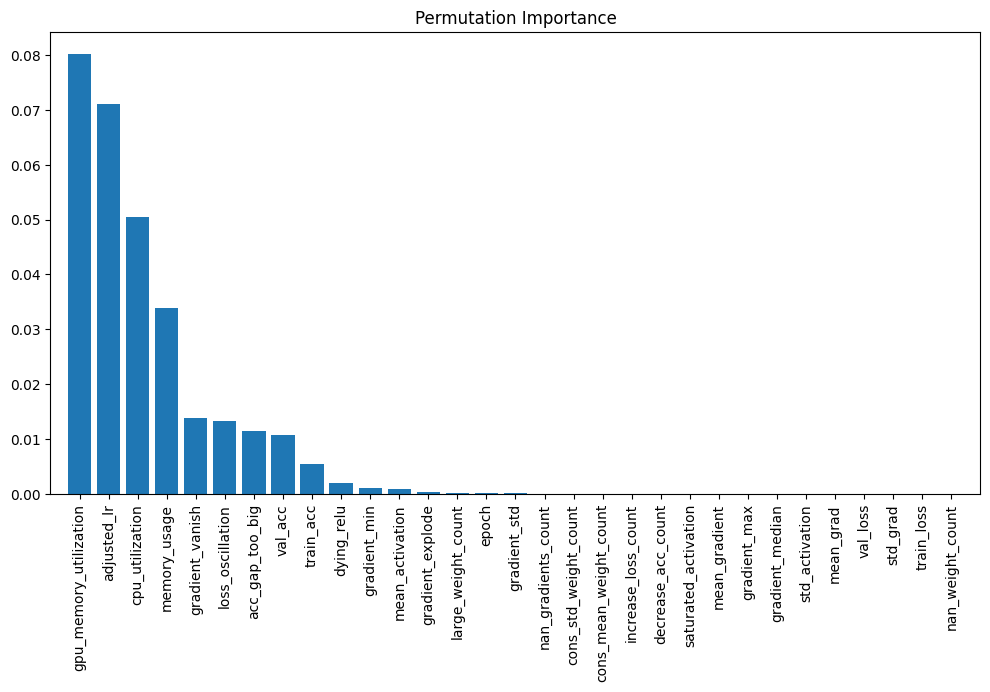

In [5]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
indices = result.importances_mean.argsort()[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Permutation Importance")
plt.bar(range(X_train.shape[1]), result.importances_mean[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


Feature ranking:
1. feature 23 (0.258864)
2. feature 24 (0.178569)
3. feature 6 (0.098995)
4. feature 4 (0.096626)
5. feature 9 (0.058348)
6. feature 29 (0.052056)
7. feature 2 (0.048642)
8. feature 7 (0.043047)
9. feature 30 (0.042593)
10. feature 28 (0.036121)
11. feature 21 (0.025970)
12. feature 8 (0.019540)
13. feature 0 (0.014172)
14. feature 10 (0.014131)
15. feature 5 (0.011031)
16. feature 25 (0.001294)
17. feature 17 (0.000000)
18. feature 22 (0.000000)
19. feature 1 (0.000000)
20. feature 27 (0.000000)


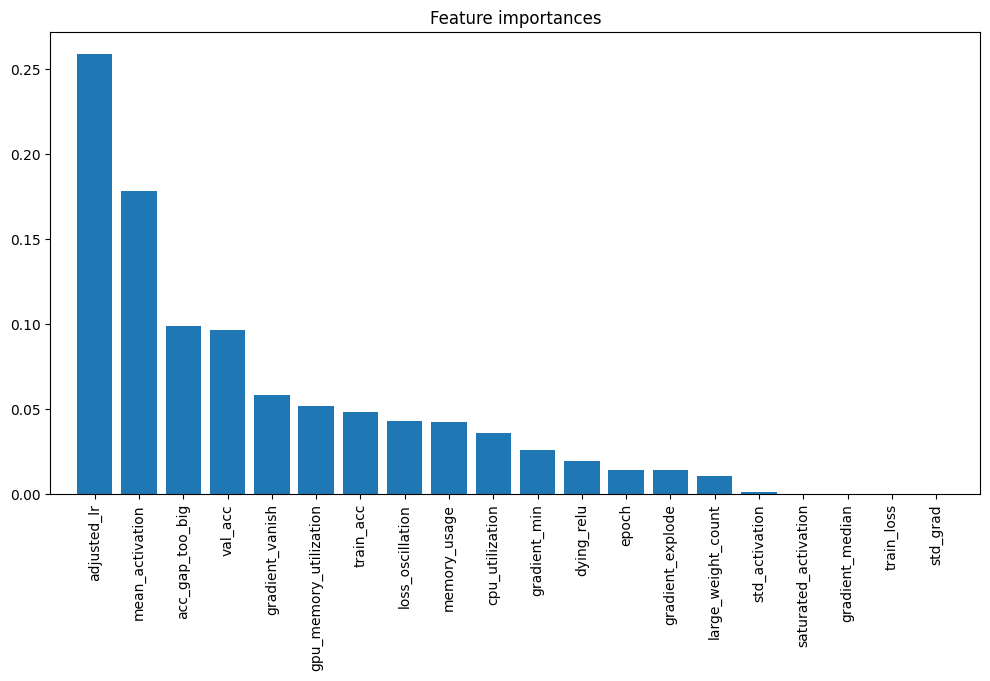

In [6]:
model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# print top 20 features with their name and index and score
feature_names = X.columns
feature_scores = model.feature_importances_
indices = np.argsort(feature_scores)[::-1]
print("Feature ranking:")
for f in range(20):
    print("%d. feature %d (%f)" % (f + 1, indices[f], feature_scores[indices[f]]))

# plot the top 20 features
feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(20), feature_scores[indices][:20], align="center")
plt.xticks(range(20), feature_names[:20], rotation=90)
plt.xlim([-1, 20])
plt.show()

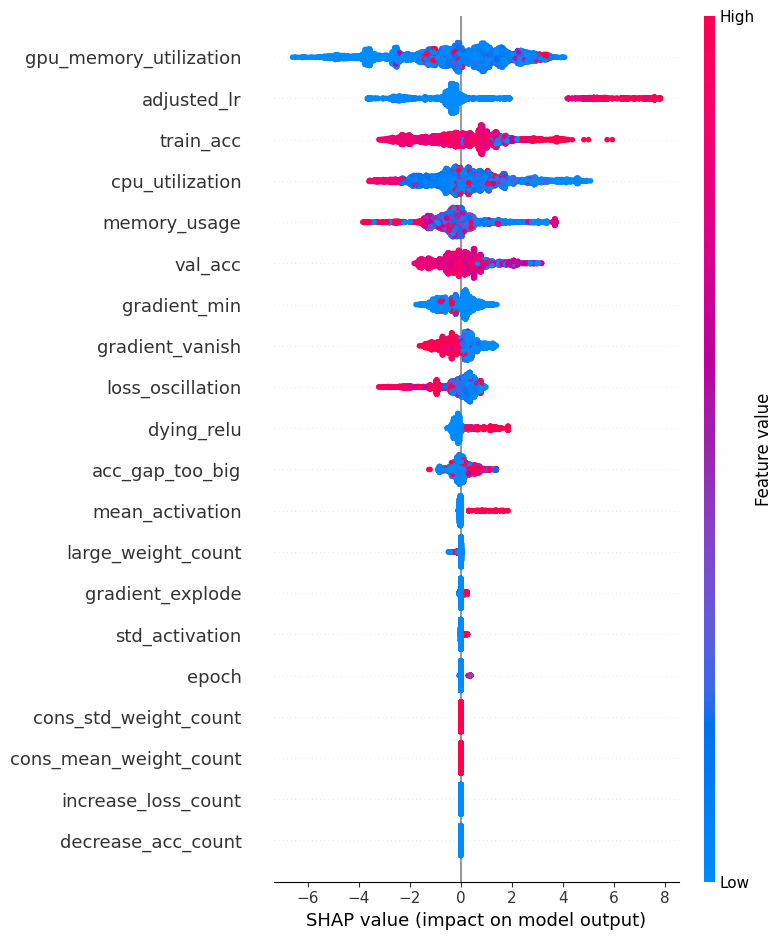

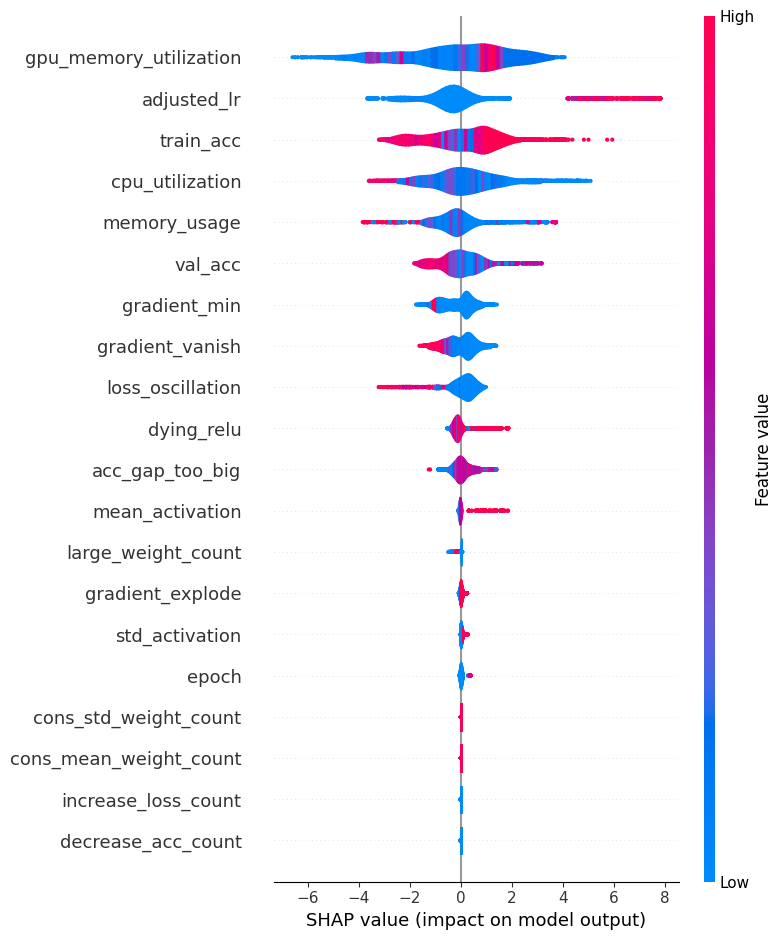

In [8]:
# Shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
feature_names = X.columns
shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type='dot')
shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type='violin')

Feature ranking:
1. feature 23 (3.054909)
2. feature 0 (1.003447)
3. feature 2 (-0.721093)
4. feature 24 (0.519190)
5. feature 21 (-0.515063)
6. feature 9 (-0.512680)
7. feature 6 (0.456574)
8. feature 19 (0.387547)
9. feature 30 (-0.346202)
10. feature 5 (-0.326178)
11. feature 13 (0.308042)
12. feature 14 (0.308042)
13. feature 8 (0.304623)
14. feature 29 (0.275414)
15. feature 16 (0.250587)
16. feature 15 (0.250435)
17. feature 7 (-0.237951)
18. feature 22 (-0.165998)
19. feature 27 (-0.163458)
20. feature 1 (-0.141403)
21. feature 18 (0.127410)
22. feature 28 (-0.125169)
23. feature 25 (0.124559)
24. feature 3 (-0.120540)
25. feature 20 (0.116153)
26. feature 4 (0.065862)
27. feature 26 (0.054375)
28. feature 10 (-0.033874)
29. feature 12 (0.000000)
30. feature 11 (0.000000)
31. feature 17 (0.000000)


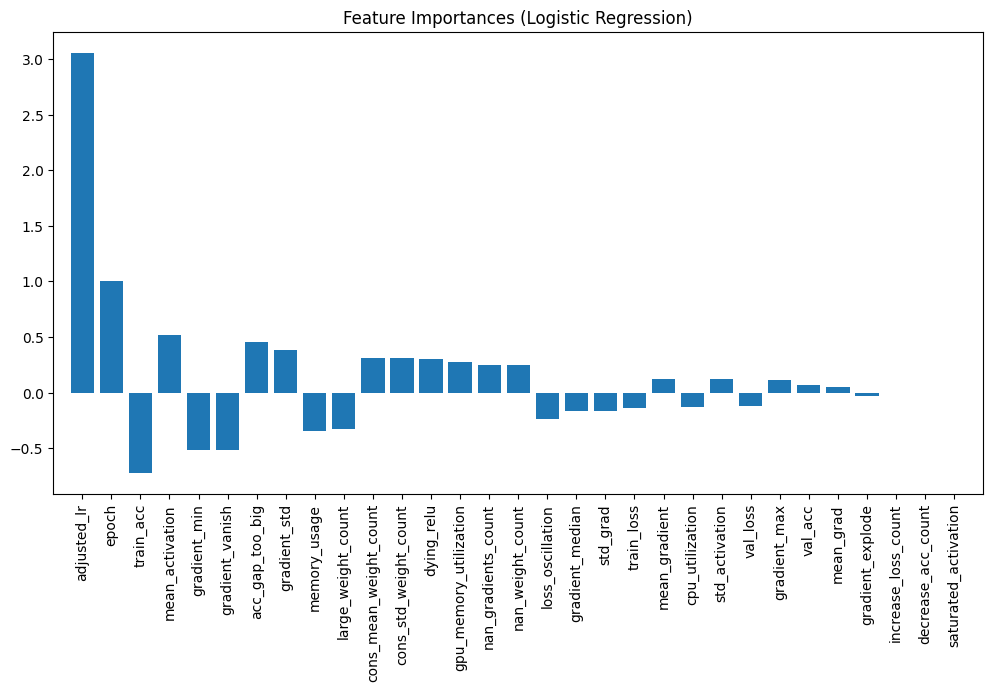

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
importance = model.coef_[0]
indices = np.argsort(np.abs(importance))[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importance[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X_train.shape[1]), importance[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


# Tree-based classifier

In [54]:
# def run_models_classification_report(X_train, X_test, y_train, y_test, verbose=True):
#     models = {
#         'LogisticRegression': LogisticRegression(max_iter=1000),
#         'DecisionTree': DecisionTreeClassifier(),
#         'RandomForest': RandomForestClassifier(),
#         'SVC': SVC(max_iter=1000),
#         'KNeighbors': KNeighborsClassifier(),
#         'MLP': MLPClassifier(max_iter=1000),
#         'GradientBoosting': GradientBoostingClassifier(),
#         'AdaBoost': AdaBoostClassifier(),
#         'Bagging': BaggingClassifier(),
#         'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
#     }
    
#     results = {}
#     cv_results = {}

#     for model_name, model in tqdm(models.items(), desc='Training Models', total=len(models)):
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         results[model_name] = classification_report(y_test, y_pred, output_dict=True)
        
#         cv_scores = cross_val_score(model, X_train, y_train, cv=5)
#         cv_results[model_name] = cv_scores
        
#         if verbose:
#             print(model_name)
#             print("Classification Report:")
#             print(classification_report(y_test, y_pred))
#             print("Cross-Validation Scores:")
#             print(cv_scores)
#             print("Mean CV Score:", cv_scores.mean())
#             print("Standard Deviation of CV Scores:", cv_scores.std())
#             print()
            
#     return results, cv_results

# # Run the models
# results, cv_results = run_models_classification_report(X_train, X_test, y_train, y_test, verbose=False)

# for model_name in results.keys():
#     print(model_name)
#     print("Classification Report:")
#     print(results[model_name])
#     print("Cross-Validation Scores:")
#     print(cv_results[model_name])
#     print("Mean CV Score:", cv_results[model_name].mean())
#     print("Standard Deviation of CV Scores:", cv_results[model_name].std())
#     print()

Training Models:  30%|███       | 3/10 [00:00<00:01,  6.35it/s]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Training Models:  70%|███████   | 7/10 [00:12<00:06,  2.24s/it]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
Training Models: 100%|██████████| 10/10 [00:13<00:00,  1.32s/it]

LogisticRegression
{'0': {'precision': 0.7251655629139073, 'recall': 0.8248587570621468, 'f1-score': 0.771806167400881, 'support': 531.0}, '1': {'precision': 0.7811764705882352, 'recall': 0.6666666666666666, 'f1-score': 0.7193932827735645, 'support': 498.0}, 'accuracy': 0.7482993197278912, 'macro avg': {'precision': 0.7531710167510712, 'recall': 0.7457627118644068, 'f1-score': 0.7455997250872228, 'support': 1029.0}, 'weighted avg': {'precision': 0.752272882662999, 'recall': 0.7482993197278912, 'f1-score': 0.7464401649281857, 'support': 1029.0}}

DecisionTree
{'0': {'precision': 0.9758812615955473, 'recall': 0.9905838041431262, 'f1-score': 0.983177570093458, 'support': 531.0}, '1': {'precision': 0.9897959183673469, 'recall': 0.9738955823293173, 'f1-score': 0.9817813765182186, 'support': 498.0}, 'accuracy': 0.9825072886297376, 'macro avg': {'precision': 0.9828385899814471, 'recall': 0.9822396932362217, 'f1-score': 0.9824794733058383, 'support': 1029.0}, 'weighted avg': {'precision': 0.98

In [11]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
k = 20
X_train_selected = X_train[:, indices[:k]]
X_test_selected = X_test[:, indices[:k]]
print("Feature ranking:")
for f in range(X_train_selected.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'] 
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid=param_grid,
    cv=5, 
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_selected)
target_names = [str(cat) for cat in encoder.categories_[0]]

print(classification_report(y_test, y_pred, target_names=target_names))
print("OOB Score of Best Model: ", best_clf.oob_score_)
print("Best Parameters: ", grid_search.best_params_)

Feature ranking:
1. feature 29 (0.166730)
2. feature 28 (0.124247)
3. feature 23 (0.123479)
4. feature 2 (0.121814)
5. feature 30 (0.103176)
6. feature 4 (0.099273)
7. feature 7 (0.058247)
8. feature 9 (0.052710)
9. feature 6 (0.047726)
10. feature 8 (0.023587)
11. feature 5 (0.015575)
12. feature 21 (0.014328)
13. feature 10 (0.008572)
14. feature 24 (0.008094)
15. feature 25 (0.006228)
16. feature 19 (0.005908)
17. feature 0 (0.004649)
18. feature 20 (0.004104)
19. feature 18 (0.004027)
20. feature 3 (0.001624)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       531
           1       1.00      0.97      0.98       498

    accuracy                           0.99      1029
   macro avg       0.99      0.99      0.99      1029
weighted avg       0.99      0.99      0.99      1029

OOB Score of Best Model:  0.9895453440311208
Best Parameters:  {'max_depth': None, 'max_fe

In [12]:
target_names = ['Not Hyperparameter', 'Hyperparameter'] 

explainer = LimeTabularExplainer(
    training_data=X_train_selected,  
    feature_names=[f'feature_{i}' for i in range(X_train_selected.shape[1])],  
    class_names=target_names,  
    mode='classification'
)

i = 2
exp = explainer.explain_instance(X_test_selected[i], best_clf.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True, show_all=False)
plt.savefig('lime_explanation.png')

<Figure size 640x480 with 0 Axes>